BUSINESS PROBLEM:
In order to effectively produce quality decisions in the modern credit card industry, knowledge 
must be gained through effective data analysis and modeling. Through the use of dynamic datadriven decision-making tools and procedures, information can be gathered to successfully evaluate 
all aspects of credit card operations. PSPD Bank has banking operations in more than 50 countries 
across the globe. Mr. Jim Watson, CEO, wants to evaluate areas of bankruptcy, fraud, and 
collections, respond to customer requests for help with proactive offers and service.

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os

In [291]:
def continuous_var_summary( x ):
    
    # freq and missings
    n_total = x.shape[0]
    n_miss = x.isna().sum()
    perc_miss = n_miss * 100 / n_total
    
    # outliers - iqr
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lc_iqr = q1 - 1.5 * iqr
    uc_iqr = q3 + 1.5 * iqr
    
    
    return pd.Series( [ x.dtype, x.nunique(), n_total, x.count(), n_miss, perc_miss,
                       x.sum(), x.mean(), x.std(), x.var(), 
                       lc_iqr, uc_iqr, 
                       x.min(), x.quantile(0.01), x.quantile(0.05), x.quantile(0.10), 
                       x.quantile(0.25), x.quantile(0.5), x.quantile(0.75), 
                       x.quantile(0.90), x.quantile(0.95), x.quantile(0.99), x.max() ], 
                     
                    index = ['dtype', 'cardinality', 'n_tot', 'n', 'nmiss', 'perc_miss',
                             'sum', 'mean', 'std', 'var',
                        'lc_iqr', 'uc_iqr',
                        'min', 'p1', 'p5', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99', 'max'])

1. In the above dataset,
 a. In case age is less than 18, replace it with mean of age values.

In [292]:
customer = pd.read_csv("C:/Users/User/MachineLearning/PythonDatasets/CustomerAcqusition.csv",usecols=["Customer","Age","City","Product","Limit","Company","Segment"])

In [293]:
repayment = pd.read_csv("C:/Users/User/MachineLearning/PythonDatasets/Repayment.csv",usecols=["Customer","Month","Amount"])

In [294]:
spend = pd.read_csv("C:/Users/User/MachineLearning/PythonDatasets/spend.csv",usecols=["Customer","Month","Type","Amount"])

In [386]:
#customer1 = customer.apply(continuous_var_summary)
#print(customer1)

In [295]:
customer.head()

,Customer,Age,City,Product,Limit,Company,Segment
0,A1,76,BANGALORE,Gold,500000.0,C1,Self Employed
1,A2,71,CALCUTTA,Silver,100000.0,C2,Salaried_MNC
2,A3,34,COCHIN,Platimum,10000.0,C3,Salaried_Pvt
3,A4,47,BOMBAY,Platimum,10001.0,C4,Govt
4,A5,56,BANGALORE,Platimum,10002.0,C5,Normal Salary


In [296]:
repayment.head()

,Customer,Month,Amount
0,A1,12-Jan-04,495414.75
1,A1,3-Jan-04,245899.02
2,A1,15-Jan-04,259490.06
3,A1,25-Jan-04,437555.12
4,A1,17-Jan-05,165972.88


In [297]:
spend.head()

,Customer,Month,Type,Amount
0,A1,12-Jan-04,JEWELLERY,485470.80
1,A1,3-Jan-04,PETRO,410556.13
2,A1,15-Jan-04,CLOTHES,23740.46
3,A1,25-Jan-04,FOOD,484342.47
4,A1,17-Jan-05,CAMERA,369694.07


In [298]:
avg_age = customer["Age"].mean()
avg_age

46.49

In [299]:
customer[customer["Age"] < 18] 

,Customer,Age,City,Product,Limit,Company,Segment
13,A14,16,BANGALORE,Gold,500000.0,C14,Salaried_Pvt
40,A41,13,COCHIN,Platimum,500000.0,C23,Govt
62,A63,15,BANGALORE,Gold,500000.0,C25,Self Employed
67,A68,12,TRIVANDRUM,Silver,100000.0,C30,Self Employed
69,A70,16,BOMBAY,Platimum,10001.0,C32,Self Employed
89,A90,16,COCHIN,Gold,500000.0,C13,Govt


In [300]:
customer.loc[customer["Age"] < 18,"Age"] = customer["Age"].mean()

C:\Users\User\AppData\Local\Temp\ipykernel_13796\1858449082.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '46.49' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  customer.loc[customer["Age"] < 18,"Age"] = customer["Age"].mean()


In [301]:
customer[customer['Age']==46.49]

,Customer,Age,City,Product,Limit,Company,Segment
13,A14,46.49,BANGALORE,Gold,500000.0,C14,Salaried_Pvt
40,A41,46.49,COCHIN,Platimum,500000.0,C23,Govt
62,A63,46.49,BANGALORE,Gold,500000.0,C25,Self Employed
67,A68,46.49,TRIVANDRUM,Silver,100000.0,C30,Self Employed
69,A70,46.49,BOMBAY,Platimum,10001.0,C32,Self Employed
89,A90,46.49,COCHIN,Gold,500000.0,C13,Govt


In [302]:
spend.isnull().sum()

Customer    0
Month       0
Type        0
Amount      0
dtype: int64

In [303]:
spend.dropna(axis = 0, how='all', inplace=True)

In [304]:
spend.dropna(axis = 1, how='all', inplace=True)

In [305]:
repayment.dropna(axis = 0, how='all', inplace=True)

In [306]:
repayment.dropna(axis = 1, how='all', inplace=True)

In [307]:
repayment['Month']=pd.to_datetime(repayment.Month, format = '%d-%b-%y')

In [308]:
repayment

,Customer,Month,Amount
0,A1,2004-01-12,495414.75
1,A1,2004-01-03,245899.02
2,A1,2004-01-15,259490.06
3,A1,2004-01-25,437555.12
4,A1,2005-01-17,165972.88
...,...,...,...
1495,A67,2005-05-09,55638.77
1496,A68,2006-05-10,319836.49
1497,A69,2006-07-11,247628.45
1498,A70,2005-08-12,454016.51


In [309]:
customer_spend = pd.merge(left = customer, right=spend, 
                             how ='inner', left_on='Customer', right_on='Customer')

In [310]:
customer_spend.head()

,Customer,Age,City,Product,Limit,Company,Segment,Month,Type,Amount
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,3-Jan-04,PETRO,410556.13
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,15-Jan-04,CLOTHES,23740.46
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,25-Jan-04,FOOD,484342.47
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,17-Jan-05,CAMERA,369694.07


b. In case spend amount is more than the limit, replace it with 50% of that customer’s limit. 
(customer’s limit provided in acquisition table is the per transaction limit on his card)


In [311]:
customer_spend[customer_spend.Amount>customer_spend.Limit].head()

,Customer,Age,City,Product,Limit,Company,Segment,Month,Type,Amount
18,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,3-Jan-04,RENTAL,199554.72
19,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,28-Feb-05,TRAIN TICKET,376887.49
20,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,6-Apr-04,BUS TICKET,439648.53
21,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,23-Nov-04,PETRO,384078.73
22,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,3-Sep-05,JEWELLERY,117089.16


In [312]:
customer_spend.rename(columns={'Amount': 'Spent_Amount','Month': 'Spent_date'}, inplace=True)

In [313]:
customer_spend[customer_spend.Spent_Amount>customer_spend.Limit].head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount
18,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,3-Jan-04,RENTAL,199554.72
19,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,28-Feb-05,TRAIN TICKET,376887.49
20,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,6-Apr-04,BUS TICKET,439648.53
21,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,23-Nov-04,PETRO,384078.73
22,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,3-Sep-05,JEWELLERY,117089.16


In [314]:
customer_spend['Spent_Amount']=np.where(customer_spend.Spent_Amount>customer_spend.Limit,
        0.5 * customer_spend.Limit, customer_spend.Spent_Amount )

In [315]:
# Now there are no customers left whose spend amount is more than the limit
customer_spend[customer_spend.Spent_Amount>customer_spend.Limit].head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount


(c) Incase the repayment amount is more than the limit, replace the repayment with the limit.

In [316]:
customer_repayment = pd.merge(left=customer, right=repayment, how='inner', left_on='Customer', right_on='Customer')

In [317]:
customer_repayment

,Customer,Age,City,Product,Limit,Company,Segment,Month,Amount
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,495414.75
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,245899.02
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-15,259490.06
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-25,437555.12
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2005-01-17,165972.88
...,...,...,...,...,...,...,...,...,...
1495,A96,54.0,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,2004-01-25,310992.30
1496,A97,58.0,TRIVANDRUM,Platimum,10000.0,C20,Govt,2004-01-12,121874.90
1497,A98,51.0,CALCUTTA,Platimum,10001.0,C21,Normal Salary,2004-01-03,337815.57
1498,A99,35.0,CALCUTTA,Platimum,10002.0,C22,Self Employed,2004-01-15,25682.73


In [318]:
customer_repayment.rename(columns={'Amount': 'Repayment_Amount','Month': 'Repayment_date'}, inplace=True)

In [319]:
customer_repayment[customer_repayment.Repayment_Amount>customer_repayment.Limit]

,Customer,Age,City,Product,Limit,Company,Segment,Repayment_date,Repayment_Amount
18,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,2004-01-03,185955.07
19,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,2005-02-28,412783.34
20,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,2004-04-06,148038.67
21,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,2004-11-23,179144.68
23,A2,71.0,CALCUTTA,Silver,100000.0,C2,Salaried_MNC,2005-08-03,381635.66
...,...,...,...,...,...,...,...,...,...
1486,A87,27.0,CALCUTTA,Silver,100003.0,C10,Govt,2006-03-30,462283.02
1495,A96,54.0,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,2004-01-25,310992.30
1496,A97,58.0,TRIVANDRUM,Platimum,10000.0,C20,Govt,2004-01-12,121874.90
1497,A98,51.0,CALCUTTA,Platimum,10001.0,C21,Normal Salary,2004-01-03,337815.57


In [320]:
customer_repayment['Repayment_Amount']=np.where(customer_repayment.Repayment_Amount>customer_repayment.Limit,
        customer_repayment.Limit, customer_repayment.Repayment_Amount )

In [321]:
customer_repayment

,Customer,Age,City,Product,Limit,Company,Segment,Repayment_date,Repayment_Amount
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,495414.75
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,245899.02
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-15,259490.06
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-25,437555.12
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2005-01-17,165972.88
...,...,...,...,...,...,...,...,...,...
1495,A96,54.0,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,2004-01-25,100000.00
1496,A97,58.0,TRIVANDRUM,Platimum,10000.0,C20,Govt,2004-01-12,10000.00
1497,A98,51.0,CALCUTTA,Platimum,10001.0,C21,Normal Salary,2004-01-03,10001.00
1498,A99,35.0,CALCUTTA,Platimum,10002.0,C22,Self Employed,2004-01-15,10002.00


In [322]:
#there are no customers left whose repayment amount is more than the limit
customer_repayment[customer_repayment.Repayment_Amount>customer_repayment.Limit]

,Customer,Age,City,Product,Limit,Company,Segment,Repayment_date,Repayment_Amount


(2) From the above dataset create the following summaries:
(a) How many distinct customers exist?

In [323]:
distinct_cust = customer.Customer.nunique()
print(f"Number of distinct customers are :",distinct_cust)

Number of distinct customers are : 100


(b) How many distinct categories exist?

In [324]:
customer['Segment'].nunique() # Display the number of categories

5

In [325]:
customer['Segment'].value_counts() # Display the numer of customers under each category

Segment
Govt             29
Self Employed    23
Normal Salary    22
Salaried_MNC     13
Salaried_Pvt     13
Name: count, dtype: int64

c. What is the average monthly spend by customers?


In [326]:
spend.head()

,Customer,Month,Type,Amount
0,A1,12-Jan-04,JEWELLERY,485470.80
1,A1,3-Jan-04,PETRO,410556.13
2,A1,15-Jan-04,CLOTHES,23740.46
3,A1,25-Jan-04,FOOD,484342.47
4,A1,17-Jan-05,CAMERA,369694.07


In [327]:
spend['Month']=pd.to_datetime(spend['Month'],format="%d-%b-%y")

In [328]:
spend.rename(columns={'Amount': 'Spent_Amount','Month': 'Spent_date'}, inplace=True)

In [329]:
spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Customer      1500 non-null   object        
 1   Spent_date    1500 non-null   datetime64[ns]
 2   Type          1500 non-null   object        
 3   Spent_Amount  1500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 47.0+ KB


In [330]:
spend['Monthly']=spend['Spent_date'].dt.strftime('%b')
spend['Yearly']=spend['Spent_date'].dt.strftime('%Y')

In [331]:
spend.head()

,Customer,Spent_date,Type,Spent_Amount,Monthly,Yearly
0,A1,2004-01-12,JEWELLERY,485470.80,Jan,2004
1,A1,2004-01-03,PETRO,410556.13,Jan,2004
2,A1,2004-01-15,CLOTHES,23740.46,Jan,2004
3,A1,2004-01-25,FOOD,484342.47,Jan,2004
4,A1,2005-01-17,CAMERA,369694.07,Jan,2005


In [332]:
customer_spend_group= round(spend.groupby(['Yearly','Monthly'])['Spent_Amount'].mean(),2)

In [333]:
customer_spend_group

Yearly  Monthly
2004    Apr        235272.04
        Feb        221215.27
        Jan        251712.07
        Mar        232146.12
        May        217539.24
        Nov        270486.40
        Sep        310923.38
2005    Apr        252181.33
        Aug        233734.63
        Dec        147503.06
        Feb        229802.28
        Jan        292741.37
        Jul        229116.66
        Jun        262688.11
        May        245696.52
        Nov        286143.32
        Oct        194568.64
        Sep        188666.20
2006    Apr        232468.97
        Aug        240699.72
        Dec        270470.98
        Feb        253858.26
        Jan        282058.01
        Jul        287505.10
        Jun        177252.39
        Mar        247166.08
        May        236162.74
        Nov        182841.29
        Oct        236136.34
        Sep        158520.09
Name: Spent_Amount, dtype: float64

In [334]:
repayment.head()

,Customer,Month,Amount
0,A1,2004-01-12,495414.75
1,A1,2004-01-03,245899.02
2,A1,2004-01-15,259490.06
3,A1,2004-01-25,437555.12
4,A1,2005-01-17,165972.88


What is the average monthly repayment by customers?

In [335]:
repayment['Month']=pd.to_datetime(repayment['Month'],format="%Y-%b-%d") #Change it to datetime object

In [336]:
repayment.rename(columns={'Amount': 'Repayment_Amount','Month': 'Repayment_date'}, inplace=True) # Rename the columns

In [337]:
repayment['Monthly']=repayment['Repayment_date'].dt.strftime('%b') # Extract month alone
repayment['Yearly']=repayment['Repayment_date'].dt.strftime('%Y')  # Extract year alone

In [338]:
customer_repayment_group= round(repayment.groupby(['Yearly','Monthly'])['Repayment_Amount'].mean(),2) # find mean by grouping the data month/year wise 

In [339]:
customer_repayment_group

Yearly  Monthly
2004    Apr        259141.68
        Feb        256702.63
        Jan        243489.65
        Mar        252585.28
        May        226162.72
        Nov        209592.24
        Sep        184487.85
2005    Apr        212688.63
        Aug        264430.92
        Dec        320379.34
        Feb        238829.27
        Jan        240548.10
        Jul        239871.48
        Jun        210199.82
        May        263207.37
        Nov        256695.12
        Oct        219849.96
        Sep        247700.17
2006    Apr        275472.25
        Aug        224143.99
        Dec        252736.57
        Feb        284489.57
        Jan        293475.39
        Jul        257936.38
        Jun        251990.45
        Mar        240851.27
        May        256920.88
        Nov        199399.20
        Oct        260765.48
        Sep        262533.88
Name: Repayment_Amount, dtype: float64

e. If the monthly rate of interest is 2.9%, what is the profit for the bank for each month? 
(Profit is defined as interest earned on Monthly Profit. Monthly Profit = Monthly repayment 
– Monthly spend. Interest is earned only on positive profits and not on negative amounts)


In [340]:
bank_profit = pd.merge(left=customer_spend,right=repayment,how='inner',on='Customer')

In [341]:
bank_profit

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Repayment_date,Repayment_Amount,Monthly,Yearly
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-12,495414.75,Jan,2004
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-03,245899.02,Jan,2004
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-15,259490.06,Jan,2004
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-25,437555.12,Jan,2004
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2005-01-17,165972.88,Jan,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37279,A96,54.0,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,25-Jan-04,BIKE,54729.66,2004-01-25,310992.30,Jan,2004
37280,A97,58.0,TRIVANDRUM,Platimum,10000.0,C20,Govt,12-Jan-04,AUTO,5000.00,2004-01-12,121874.90,Jan,2004
37281,A98,51.0,CALCUTTA,Platimum,10001.0,C21,Normal Salary,3-Jan-04,SHOPPING,5000.50,2004-01-03,337815.57,Jan,2004
37282,A99,35.0,CALCUTTA,Platimum,10002.0,C22,Self Employed,15-Jan-04,AIR TICKET,5001.00,2004-01-15,25682.73,Jan,2004


In [342]:
bank_profit

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Repayment_date,Repayment_Amount,Monthly,Yearly
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-12,495414.75,Jan,2004
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-03,245899.02,Jan,2004
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-15,259490.06,Jan,2004
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2004-01-25,437555.12,Jan,2004
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,2005-01-17,165972.88,Jan,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37279,A96,54.0,CHENNAI,Silver,100000.0,C19,Salaried_Pvt,25-Jan-04,BIKE,54729.66,2004-01-25,310992.30,Jan,2004
37280,A97,58.0,TRIVANDRUM,Platimum,10000.0,C20,Govt,12-Jan-04,AUTO,5000.00,2004-01-12,121874.90,Jan,2004
37281,A98,51.0,CALCUTTA,Platimum,10001.0,C21,Normal Salary,3-Jan-04,SHOPPING,5000.50,2004-01-03,337815.57,Jan,2004
37282,A99,35.0,CALCUTTA,Platimum,10002.0,C22,Self Employed,15-Jan-04,AIR TICKET,5001.00,2004-01-15,25682.73,Jan,2004


In [343]:
interest_df = bank_profit.groupby(["Yearly","Monthly"])[['Spent_Amount','Repayment_Amount']].agg({'Spent_Amount':np.sum,'Repayment_Amount':np.sum})

C:\Users\User\AppData\Local\Temp\ipykernel_13796\3464962675.py:1: FutureWarning: The provided callable <function sum at 0x000001DE9F3BB7E0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  interest_df = bank_profit.groupby(["Yearly","Monthly"])[['Spent_Amount','Repayment_Amount']].agg({'Spent_Amount':np.sum,'Repayment_Amount':np.sum})
C:\Users\User\AppData\Local\Temp\ipykernel_13796\3464962675.py:1: FutureWarning: The provided callable <function sum at 0x000001DE9F3BB7E0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  interest_df = bank_profit.groupby(["Yearly","Monthly"])[['Spent_Amount','Repayment_Amount']].agg({'Spent_Amount':np.sum,'Repayment_Amount':np.sum})


In [344]:
interest_df['Monthly_Profit']=interest_df['Repayment_Amount']-interest_df['Spent_Amount']

In [345]:
interest_df

Spent_Amount  Repayment_Amount  Monthly_Profit
Yearly Monthly                                                
2004   Apr      1.194516e+08      2.285403e+08    1.090887e+08
       Feb      7.613922e+07      1.602419e+08    8.410268e+07
       Jan      1.088357e+09      1.699210e+09    6.108525e+08
       Mar      5.594171e+07      8.974470e+07    3.380298e+07
       May      8.800456e+07      1.411594e+08    5.315485e+07
       Nov      5.504612e+07      7.860290e+07    2.355678e+07
       Sep      5.144278e+07      8.016122e+07    2.871844e+07
2005   Apr      9.366405e+07      1.747894e+08    8.112539e+07
       Aug      1.361400e+08      2.477449e+08    1.116049e+08
       Dec      4.348638e+07      9.944533e+07    5.595895e+07
       Feb      5.890557e+08      9.416163e+08    3.525606e+08
       Jan      1.324129e+08      1.810333e+08    4.862042e+07
       Jul      3.995653e+07      7.997268e+07    4.001615e+07
       Jun      1.174019e+08      2.213774e+08    1.039755e+08
       May      7.149030e+08      1.099197e+09    3.842944e+08
       Nov      1.532278e+08      2.763119e+08    1.230841e+08
       Oct      3.140993e+07      6.027830e+07    2.886837e+07
       Sep      3.195551e+07      7.530449e+07    4.334898e+07
2006   Apr      3.229722e+08      6.093666e+08    2.863944e+08
       Aug      5.849630e+07      7.167032e+07    1.317402e+07
       Dec      4.585222e+07      7.087702e+07    2.502480e+07
       Feb      1.654843e+08      2.903280e+08    1.248436e+08
       Jan      5.127574e+07      8.974491e+07    3.846917e+07
       Jul      1.444093e+08      2.245720e+08    8.016271e+07
       Jun      5.302118e+07      6.914431e+07    1.612313e+07
       Mar      7.393854e+08      1.115725e+09    3.763400e+08
       May      3.297954e+08      5.434823e+08    2.136869e+08
       Nov      1.124836e+08      1.355832e+08    2.309955e+07
       Oct      5.285823e+07      7.890924e+07    2.605102e+07
       Sep      5.395681e+07      8.083199e+07    2.687518e+07

In [346]:
interest_df['Interest_Earned']=(2.9 *interest_df['Monthly_Profit'])/100

In [347]:
interest_df

Spent_Amount  Repayment_Amount  Monthly_Profit  \
Yearly Monthly                                                   
2004   Apr      1.194516e+08      2.285403e+08    1.090887e+08   
       Feb      7.613922e+07      1.602419e+08    8.410268e+07   
       Jan      1.088357e+09      1.699210e+09    6.108525e+08   
       Mar      5.594171e+07      8.974470e+07    3.380298e+07   
       May      8.800456e+07      1.411594e+08    5.315485e+07   
       Nov      5.504612e+07      7.860290e+07    2.355678e+07   
       Sep      5.144278e+07      8.016122e+07    2.871844e+07   
2005   Apr      9.366405e+07      1.747894e+08    8.112539e+07   
       Aug      1.361400e+08      2.477449e+08    1.116049e+08   
       Dec      4.348638e+07      9.944533e+07    5.595895e+07   
       Feb      5.890557e+08      9.416163e+08    3.525606e+08   
       Jan      1.324129e+08      1.810333e+08    4.862042e+07   
       Jul      3.995653e+07      7.997268e+07    4.001615e+07   
       Jun      1.174019e+08      2.213774e+08    1.039755e+08   
       May      7.149030e+08      1.099197e+09    3.842944e+08   
       Nov      1.532278e+08      2.763119e+08    1.230841e+08   
       Oct      3.140993e+07      6.027830e+07    2.886837e+07   
       Sep      3.195551e+07      7.530449e+07    4.334898e+07   
2006   Apr      3.229722e+08      6.093666e+08    2.863944e+08   
       Aug      5.849630e+07      7.167032e+07    1.317402e+07   
       Dec      4.585222e+07      7.087702e+07    2.502480e+07   
       Feb      1.654843e+08      2.903280e+08    1.248436e+08   
       Jan      5.127574e+07      8.974491e+07    3.846917e+07   
       Jul      1.444093e+08      2.245720e+08    8.016271e+07   
       Jun      5.302118e+07      6.914431e+07    1.612313e+07   
       Mar      7.393854e+08      1.115725e+09    3.763400e+08   
       May      3.297954e+08      5.434823e+08    2.136869e+08   
       Nov      1.124836e+08      1.355832e+08    2.309955e+07   
       Oct      5.285823e+07      7.890924e+07    2.605102e+07   
       Sep      5.395681e+07      8.083199e+07    2.687518e+07   

                Interest_Earned  
Yearly Monthly                   
2004   Apr         3.163572e+06  
       Feb         2.438978e+06  
       Jan         1.771472e+07  
       Mar         9.802865e+05  
       May         1.541491e+06  
       Nov         6.831466e+05  
       Sep         8.328349e+05  
2005   Apr         2.352636e+06  
       Aug         3.236542e+06  
       Dec         1.622810e+06  
       Feb         1.022426e+07  
       Jan         1.409992e+06  
       Jul         1.160468e+06  
       Jun         3.015290e+06  
       May         1.114454e+07  
       Nov         3.569438e+06  
       Oct         8.371827e+05  
       Sep         1.257121e+06  
2006   Apr         8.305437e+06  
       Aug         3.820465e+05  
       Dec         7.257193e+05  
       Feb         3.620465e+06  
       Jan         1.115606e+06  
       Jul         2.324719e+06  
       Jun         4.675707e+05  
       Mar         1.091386e+07  
       May         6.196920e+06  
       Nov         6.698869e+05  
       Oct         7.554795e+05  
       Sep         7.793803e+05

(f) What are the top 5 product types?

In [348]:
spend.head()

,Customer,Spent_date,Type,Spent_Amount,Monthly,Yearly
0,A1,2004-01-12,JEWELLERY,485470.80,Jan,2004
1,A1,2004-01-03,PETRO,410556.13,Jan,2004
2,A1,2004-01-15,CLOTHES,23740.46,Jan,2004
3,A1,2004-01-25,FOOD,484342.47,Jan,2004
4,A1,2005-01-17,CAMERA,369694.07,Jan,2005


In [349]:
#top 5 product types on which customer is spending
spend['Type'].value_counts().head()

Type
PETRO           200
FOOD            160
CAMERA          160
AIR TICKET      147
TRAIN TICKET    132
Name: count, dtype: int64

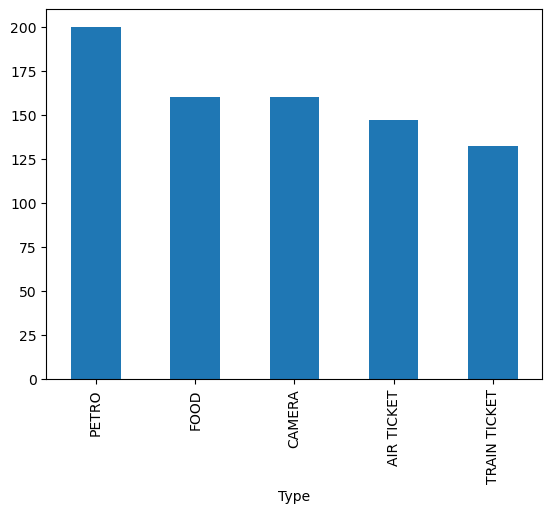

In [350]:
spend['Type'].value_counts().head(5).plot(kind='bar')
plt.show()

In [ ]:
(g) Which city is having maximum spend?

In [351]:
customer_spend.head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,3-Jan-04,PETRO,410556.13
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,15-Jan-04,CLOTHES,23740.46
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,25-Jan-04,FOOD,484342.47
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,17-Jan-05,CAMERA,369694.07


In [352]:
city_spend = customer_spend.groupby("City")["Spent_Amount"].sum().sort_values(ascending=False)

In [353]:
city_spend

City
COCHIN        45963513.50
CALCUTTA      41108132.30
BANGALORE     40461647.02
BOMBAY        28603127.38
CHENNAI       22128635.65
TRIVANDRUM    15337155.87
PATNA         15260586.97
DELHI         10918286.54
Name: Spent_Amount, dtype: float64

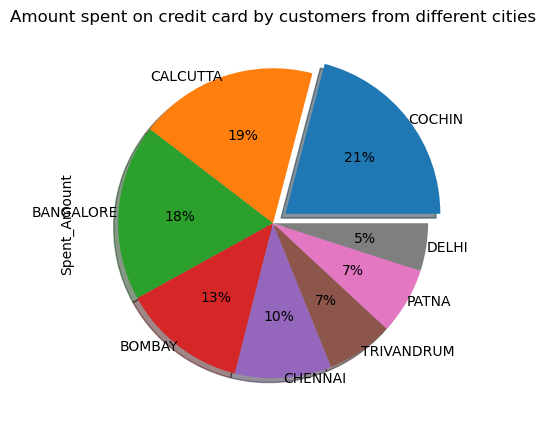

From above pie chart we can see that Cochin is having maximum spend.


In [354]:
plt.figure(figsize=(5,10))
city_spend.plot(kind="pie",autopct="%1.0f%%",shadow=True,labeldistance=1.0,explode=[0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0])
plt.title("Amount spent on credit card by customers from different cities")
plt.show()
print("From above pie chart we can see that Cochin is having maximum spend.")

(h) Which age group is spending more money?

In [355]:
#creating new column "Age Group" with 8 bins between 18 to 88 
customer_spend["Age Group"] =  pd.cut(customer_spend["Age"],bins=np.arange(18,88,8),labels=["18-26","26-34", "34-42" ,"42-50" ,"50-58","58-66","66-74","74-82"],include_lowest=True)

In [356]:
customer_spend.head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Age Group
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,74-82
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,3-Jan-04,PETRO,410556.13,74-82
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,15-Jan-04,CLOTHES,23740.46,74-82
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,25-Jan-04,FOOD,484342.47,74-82
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,17-Jan-05,CAMERA,369694.07,74-82


In [357]:
#grouping data based on "Age Group" and finding the amount spend by each age group and arranging in descending oreder
age_spend = customer_spend.groupby("Age Group")['Spent_Amount'].sum().sort_values(ascending=False)

C:\Users\User\AppData\Local\Temp\ipykernel_13796\1728216273.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spend = customer_spend.groupby("Age Group")['Spent_Amount'].sum().sort_values(ascending=False)


In [358]:
age_spend

Age Group
42-50    53242390.70
34-42    38037826.50
26-34    30553459.81
18-26    25233896.65
50-58    22454066.68
74-82    19770884.32
66-74    17705877.44
58-66    12782683.13
Name: Spent_Amount, dtype: float64

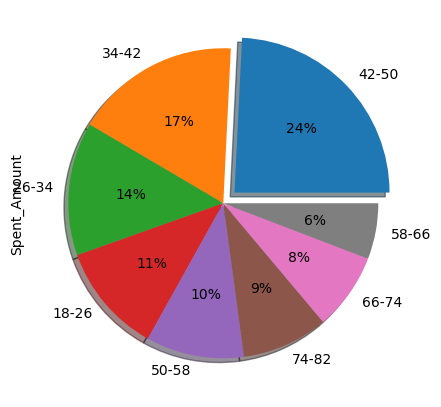

In [359]:
plt.figure(figsize=(5,10))
age_spend.plot(kind = "pie",autopct="%1.0f%%",explode=[0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0],shadow=True)
plt.show()

In [256]:
print("From the pie chart shown above we can say that age group 42 - 50 is spending more money")

From the pie chart shown above we can say that age group 42 - 50 is spending more money


(i) Who are the top 10 customers in terms of repayment?

In [360]:
customer_repayment.head()

,Customer,Age,City,Product,Limit,Company,Segment,Repayment_date,Repayment_Amount
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,495414.75
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,245899.02
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-15,259490.06
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-25,437555.12
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2005-01-17,165972.88


In [361]:
customer_repayment.groupby("Customer")[["Repayment_Amount"]].sum().sort_values(by="Repayment_Amount",ascending=False).head(10)

,Repayment_Amount
Customer,
A61,10539142.91
A60,9876290.74
A13,9572000.66
A43,8489871.46
A45,8448334.87
A12,8334760.16
A14,7943268.63
A44,7744730.12
A39,7622483.30


(3) Calculate the city wise spend on each product on yearly basis. Also include a graphical representation for the same.

In [362]:
customer_spend.head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Age Group
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,12-Jan-04,JEWELLERY,485470.80,74-82
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,3-Jan-04,PETRO,410556.13,74-82
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,15-Jan-04,CLOTHES,23740.46,74-82
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,25-Jan-04,FOOD,484342.47,74-82
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,17-Jan-05,CAMERA,369694.07,74-82


In [363]:
#converting "Month" column to date time 
customer_spend["Spent_date"] = pd.to_datetime(customer_spend["Spent_date"])

C:\Users\User\AppData\Local\Temp\ipykernel_13796\125517988.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer_spend["Spent_date"] = pd.to_datetime(customer_spend["Spent_date"])


In [364]:
customer_spend['Year'] = customer_spend['Spent_date'].apply(lambda x:pd.Timestamp.strftime(x,format="%Y"))

In [264]:
customer_spend.head(2)

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Age Group,Year
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,74-82,2004
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,PETRO,410556.13,74-82,2004


In [365]:
customer_spend_pivot = pd.pivot_table(data = customer_spend,index=["City","Year"],columns='Product',aggfunc="sum",values="Spent_Amount")

In [266]:
customer_spend_pivot

Product                 Gold    Platimum      Silver
City       Year                                     
BANGALORE  2004   9289878.54  1112732.30  1291852.58
           2005  12892362.99   912284.97   830612.34
           2006  12030611.09   685831.27  1415480.94
BOMBAY     2004   6987853.53   897264.94   532089.03
           2005   8983018.28   711804.94   508988.54
           2006   7917144.31   972130.01  1092833.80
CALCUTTA   2004   7477140.98  2037690.30   500006.00
           2005  10303355.80  4434696.31   440147.06
           2006  11167532.77  3589606.66  1157956.42
CHENNAI    2004   1059618.50  3535652.38   282056.86
           2005   3740945.58  5053956.32   377184.49
           2006   2704288.62  5024923.40   350009.50
COCHIN     2004   7315850.15  3419904.07   814229.62
           2005  12110613.03  4960921.71   652269.38
           2006  10499142.38  4920592.29  1269990.87
DELHI      2004   2806495.00   283512.89   768172.30
           2005   1964845.27   494157.86   612311.21
           2006   2957103.32   176788.72   854899.97
PATNA      2004   2072567.90  1113069.60   756684.10
           2005   3252615.77  2883231.07   950094.19
           2006   2276181.69  1256137.65   700005.00
TRIVANDRUM 2004   2415102.84  2161676.67   209667.48
           2005   1240375.85  3601443.30   269912.99
           2006   2735710.87  2147403.75   555862.12

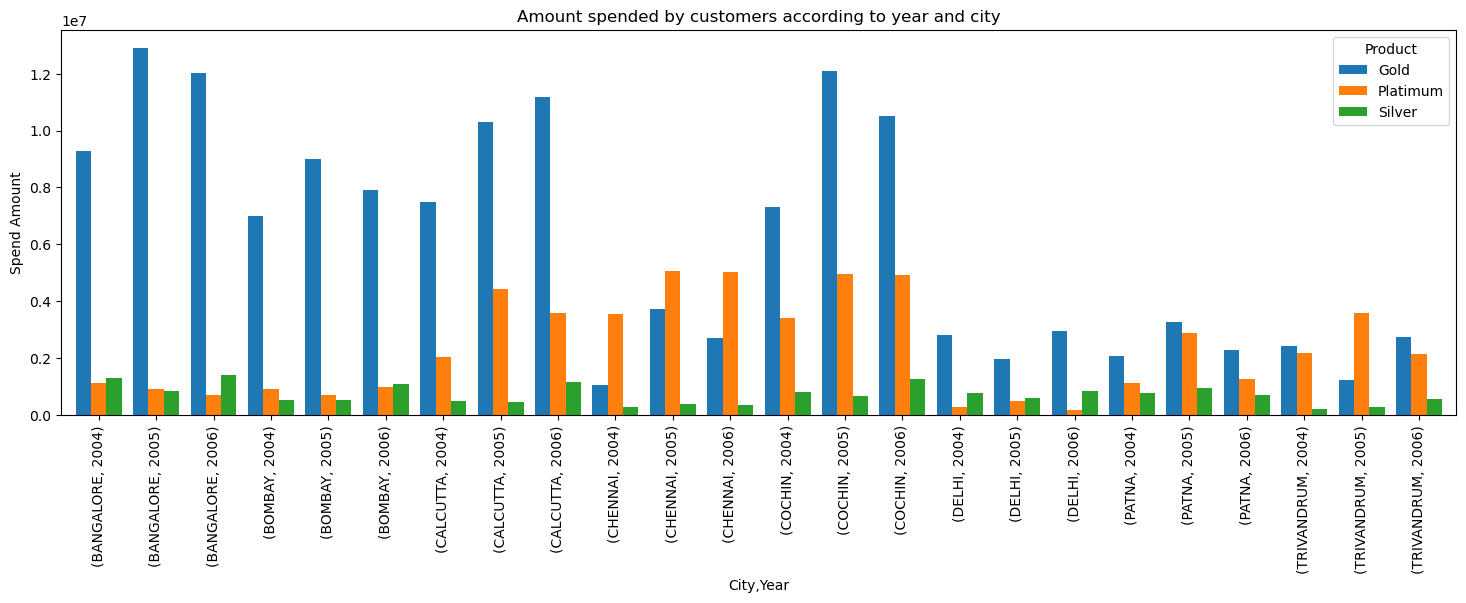

In [366]:
customer_spend_pivot.plot(kind="bar",figsize=(18,5),width=0.8)
plt.ylabel("Spend Amount")
plt.title("Amount spended by customers according to year and city")
plt.show()

(4) Create graphs for
(a) Monthly comparison of total spends, city wise

In [367]:
customer_spend.head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Age Group,Year
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,74-82,2004
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,PETRO,410556.13,74-82,2004
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-15,CLOTHES,23740.46,74-82,2004
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-25,FOOD,484342.47,74-82,2004
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2005-01-17,CAMERA,369694.07,74-82,2005


In [368]:
#creating new column "Monthly" 
customer_spend['Monthly'] = customer_spend['Spent_date'].apply(lambda x:pd.Timestamp.strftime(x,format="%B"))

In [369]:
#grouping data based on "Monthly" and "City" columns
month_city = customer_spend.groupby(["Monthly","City"])[["Spent_Amount"]].sum().sort_index().reset_index()

In [271]:
#creating pivot table based on "Monthly" and "City" columns
month_city =pd.pivot_table(data=customer_spend,values='Spent_Amount',index='City',columns='Monthly',aggfunc='sum')

In [272]:
month_city

Monthly,April,August,December,February,January,July,June,March,May,November,October,September
City,,,,,,,,,,,,
BANGALORE,4207980.48,695061.95,422167.24,6734494.76,9041796.84,2228217.69,1330685.90,5362903.07,6383115.13,2260603.07,1091602.61,703018.28
BOMBAY,1873785.01,1066744.75,140040.71,4276988.30,5948993.33,177726.32,1172594.97,5227850.50,3891945.60,2872049.40,676005.70,1278402.79
CALCUTTA,3457507.95,1548354.02,55001.50,8150545.61,9064864.90,2234573.27,2293045.81,4939040.04,5578246.87,2078880.93,196357.83,1511713.57
CHENNAI,2518656.99,305875.97,223628.27,4385815.95,4466961.36,693825.77,1244242.16,3183643.71,2856199.62,1347779.28,156247.17,745759.40
COCHIN,3882744.94,2317306.61,909533.05,5747886.38,11714373.54,1290897.30,2495745.07,5645146.53,6581085.69,3127999.60,868551.89,1382242.90
DELHI,777240.75,155402.16,842342.02,1494064.06,2714261.45,50001.50,511276.09,2267149.02,1600322.07,391610.96,64615.46,50001.00
PATNA,2338179.53,419383.64,50000.00,2353333.55,4916205.55,50000.00,746186.13,1437166.61,2136586.80,413677.87,329537.34,70329.95
TRIVANDRUM,1199293.45,453773.94,640922.26,2857123.89,3704336.99,260484.50,400336.83,2392316.51,2813534.48,143387.40,285581.92,186063.70


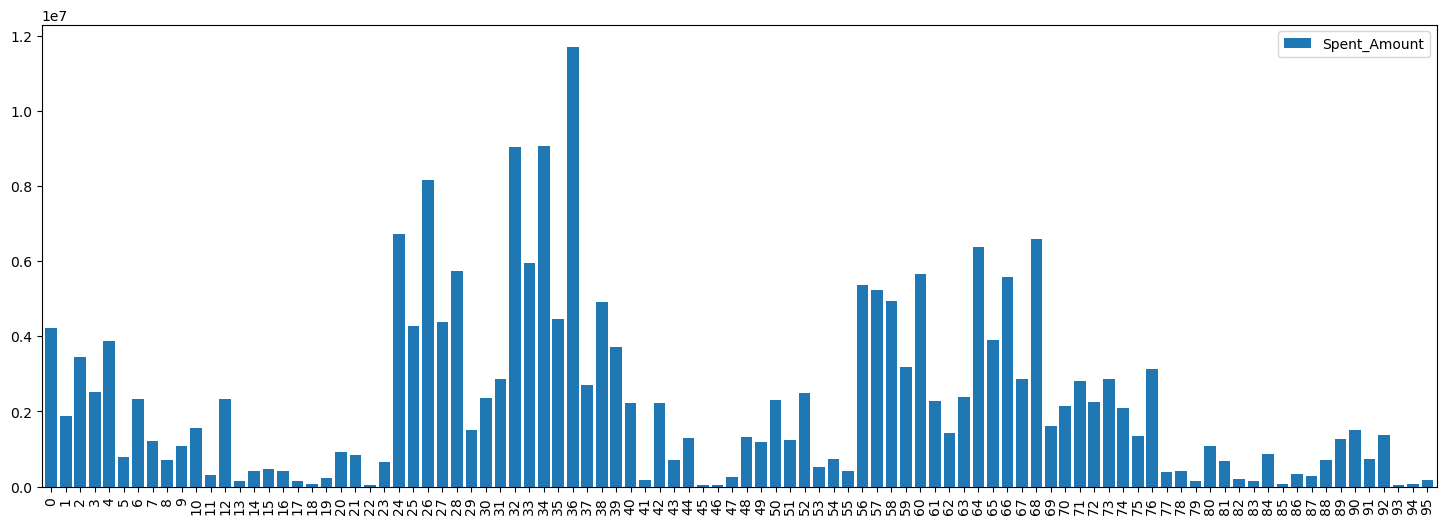

In [371]:
month_city.plot(kind="bar",figsize=(18,6),width=0.8)
plt.show()

(b) Comparison of yearly spend on air tickets

In [372]:
customer_spend.head()

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Age Group,Year,Monthly
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,74-82,2004,January
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,PETRO,410556.13,74-82,2004,January
2,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-15,CLOTHES,23740.46,74-82,2004,January
3,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-25,FOOD,484342.47,74-82,2004,January
4,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2005-01-17,CAMERA,369694.07,74-82,2005,January


In [373]:
air_tickets = customer_spend.groupby(["Year","Type"])[["Spent_Amount"]].sum().reset_index()

In [374]:
filtered = air_tickets.loc[air_tickets["Type"]=="AIR TICKET"]

In [375]:
filtered

,Year,Type,Spent_Amount
0,2004,AIR TICKET,4357225.35
15,2005,AIR TICKET,10550152.21
30,2006,AIR TICKET,5248469.56


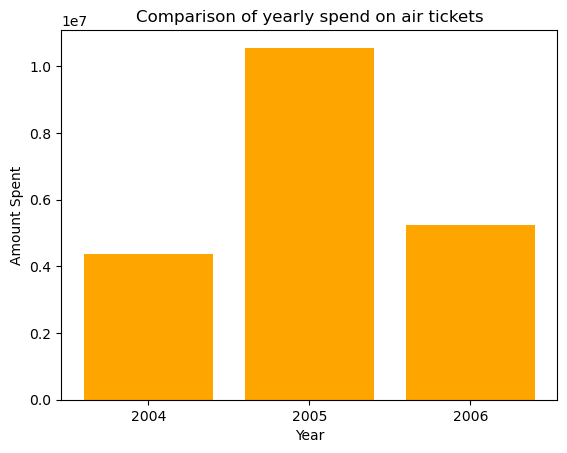

In [376]:
plt.bar(filtered["Year"],height=filtered["Spent_Amount"],color="orange")
plt.xlabel("Year")
plt.ylabel("Amount Spent")
plt.title("Comparison of yearly spend on air tickets")
plt.show()

(c) Comparison of monthly spend for each product (look for any seasonality that exists in terms of spend)

In [377]:
customer_spend.head(2)

,Customer,Age,City,Product,Limit,Company,Segment,Spent_date,Type,Spent_Amount,Age Group,Year,Monthly
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,JEWELLERY,485470.80,74-82,2004,January
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,PETRO,410556.13,74-82,2004,January


In [379]:
#creating pivot table based on "Monthly" and "Product" columns
product_wise = pd.pivot_table(data=customer_spend,index='Product',columns='Monthly',values='Spent_Amount',aggfunc='sum')

In [282]:
product_wise

Monthly,April,August,December,February,January,July,June,March,May,November,October,September
Product,,,,,,,,,,,,
Gold,13170572.59,4954030.42,2332940.96,24779179.55,32413831.83,5167416.37,6538862.64,19256972.48,21548169.76,9203267.46,3018223.38,3816887.62
Platimum,5182493.86,1714762.80,750156.19,9134054.58,14951578.51,1288156.26,2965712.71,7288837.68,8151926.49,2741618.42,550275.04,1667840.84
Silver,1902322.65,293109.82,200537.90,2087018.37,4206383.62,530153.72,689537.61,3909405.83,2140940.01,691102.63,100001.50,442803.13


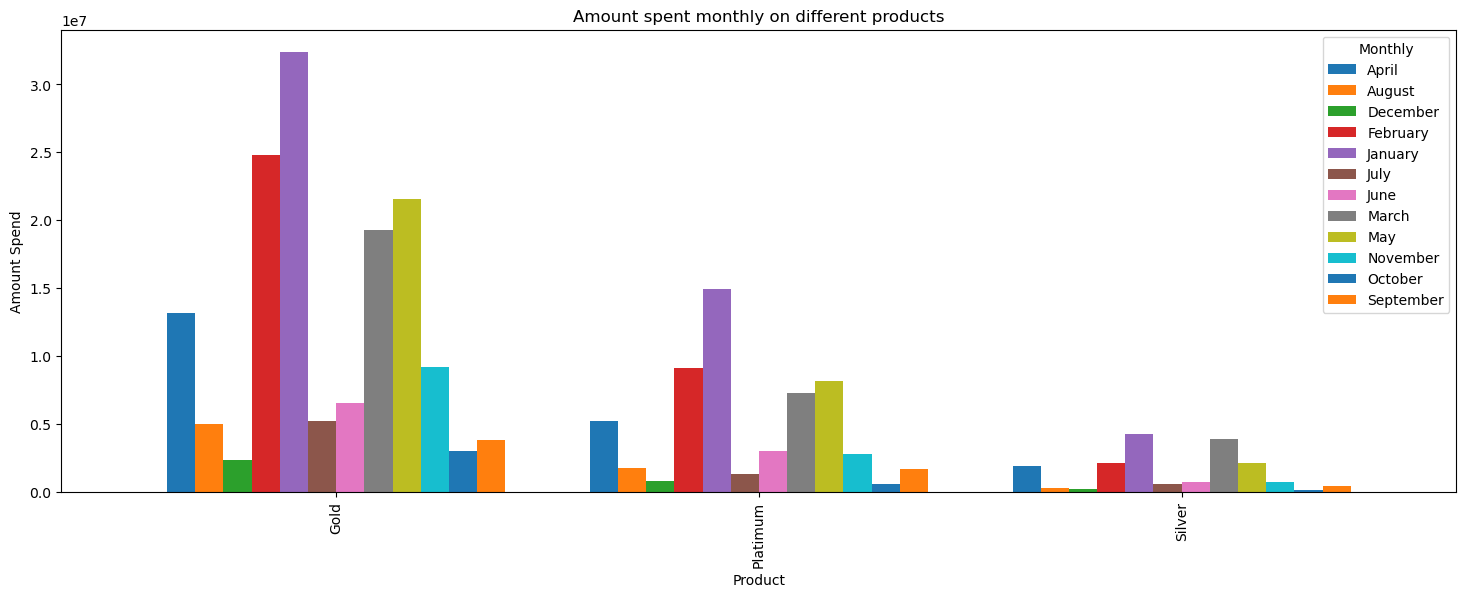

In [380]:
product_wise.plot(kind="bar",figsize=(18,6),width=0.8)
plt.ylabel("Amount Spend")
plt.title("Amount spent monthly on different products")
plt.show()

(5) Write user defined PYTHON function to perform the following analysis: You need to find top 10 customers for each city in terms of their repayment amount by different products and by different time periods i.e. year or month. The user should be able to specify the product (Gold/Silver/Platinum) and time period (yearly or monthly) and the function should automatically take these inputs while identifying the top 10 customers.

In [285]:
customer_repayment.head(2)

,Customer,Age,City,Product,Limit,Company,Segment,Repayment_date,Repayment_Amount
0,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-12,495414.75
1,A1,76.0,BANGALORE,Gold,500000.0,C1,Self Employed,2004-01-03,245899.02


In [381]:
# converting 'Month' column to date time format
customer_repayment['Repayment_date'] = pd.to_datetime(customer_repayment['Repayment_date'])

In [382]:
#creating new column "Monthly" and "Yearly" using already existing 'Month' column
customer_repayment['Monthly'] = customer_repayment['Repayment_date'].apply(lambda x:pd.Timestamp.strftime(x,format="%B"))
customer_repayment['Yearly'] = customer_repayment['Repayment_date'].apply(lambda x:pd.Timestamp.strftime(x,format="%Y"))

In [383]:
def summary_report(product,timeperiod):
    print('Give the product name and timeperiod for which you want the data')
    if product.lower()=='gold' and timeperiod.lower()=='monthly':
        pivot = customer_repayment.pivot_table(index=['Product','City','Customer'],columns='Monthly',aggfunc='sum',values='Repayment_Amount')
        result = pivot.loc[('Gold',['BANGALORE','COCHIN','CALCUTTA','BOMBAY','CHENNAI','TRIVANDRUM','PATNA','DELHI']),:]
    elif product.lower()=='gold' and timeperiod.lower()=='yearly':
        pivot = customer_repayment.pivot_table(index=['Product','City','Customer'],columns='Yearly',aggfunc='sum',values='Repayment_Amount')
        result = pivot.loc[('Gold',['BANGALORE','COCHIN','CALCUTTA','BOMBAY','CHENNAI','TRIVANDRUM','PATNA','DELHI']),:]
    elif product.lower()=='silver' and timeperiod.lower()=='monthly':
        pivot = customer_repayment.pivot_table(index=['Product','City','Customer'],columns='Monthly',aggfunc='sum',values='Repayment_Amount')
        result = pivot.loc[('Silver',['BANGALORE','COCHIN','CALCUTTA','BOMBAY','CHENNAI','TRIVANDRUM','PATNA','DELHI']),:]
    elif product.lower()=='silver' and timeperiod.lower()=='yearly':
        pivot = customer_repayment.pivot_table(index=['Product','City','Customer'],columns='Yearly',aggfunc='sum',values='Repayment_Amount')
        result = pivot.loc[('Silver',['BANGALORE','COCHIN','CALCUTTA','BOMBAY','CHENNAI','TRIVANDRUM','PATNA','DELHI']),:]
    if product.lower()=='platinum' and timeperiod.lower()=='monthly':
        pivot = customer_repayment.pivot_table(index=['Product','City','Customer'],columns='Monthly',aggfunc='sum',values='Repayment_Amount')
        result = pivot.loc[('Platinum',['BANGALORE','COCHIN','CALCUTTA','BOMBAY','CHENNAI','TRIVANDRUM','PATNA','DELHI']),:]
    elif product.lower()=='platinum' and timeperiod.lower()=='yearly':
        pivot = customer_repayment.pivot_table(index=['Product','City','Customer'],columns='Yearly',aggfunc='sum',values='Repayment_Amount')
        result = pivot.loc[('Platinum',['BANGALORE','COCHIN','CALCUTTA','BOMBAY','CHENNAI','TRIVANDRUM','PATNA','DELHI']),:]
    return result

In [384]:
summary_report('gold','monthly')

Give the product name and timeperiod for which you want the data


Monthly                           April     August   December    February  \
Product City       Customer                                                 
Gold    BANGALORE  A1         508949.16        NaN        NaN   781873.80   
                   A13        494392.40  873304.51        NaN  2049808.15   
                   A14        812582.20  198623.13  388821.96  1482923.34   
                   A30        425694.16        NaN        NaN  1321469.80   
                   A43        612541.80        NaN        NaN   763846.93   
                   A63              NaN        NaN        NaN         NaN   
                   A81              NaN        NaN        NaN         NaN   
                   A88              NaN        NaN        NaN         NaN   
                   A92        459105.69        NaN        NaN         NaN   
        COCHIN     A11        958466.08  332677.61        NaN  1069789.26   
                   A16        338710.86        NaN        NaN   331143.85   
                   A32        333042.82   99528.43        NaN   851127.91   
                   A45       1435443.21  431769.44  410935.52  1241580.90   
                   A61       3412860.60  197804.13        NaN  1345911.54   
                   A65              NaN        NaN        NaN         NaN   
                   A90        109931.32        NaN        NaN         NaN   
                   A94              NaN        NaN        NaN         NaN   
        CALCUTTA   A10        478747.41        NaN        NaN   652033.51   
                   A15              NaN   17981.25        NaN   516544.51   
                   A29              NaN  534103.41        NaN   627147.67   
                   A31         13054.67        NaN        NaN   962656.24   
                   A60       2397565.91  735660.40        NaN  1403731.08   
                   A89        497237.97        NaN        NaN         NaN   
        BOMBAY     A12        601326.07  120471.17        NaN  1978117.59   
                   A17        391463.29   98341.04  479227.30   374865.01   
                   A42        173199.87        NaN        NaN   476213.23   
                   A62       1115760.01        NaN        NaN   478764.07   
                   A91        247781.00        NaN        NaN         NaN   
        CHENNAI    A27        379529.81  472123.57  136860.63   841114.02   
                   A67              NaN        NaN        NaN         NaN   
        TRIVANDRUM A28        115326.71  437823.07  451630.26   968709.79   
        PATNA      A26        558432.60  398164.37  417177.67  1298000.32   
                   A66              NaN        NaN        NaN         NaN   
                   A95              NaN        NaN        NaN         NaN   
        DELHI      A44        346650.76  539494.72   79696.21   745752.19   
                   A64              NaN        NaN  212614.48         NaN   
                   A82              NaN        NaN        NaN         NaN   
                   A93              NaN        NaN        NaN         NaN   

Monthly                         January        July       June       March  \
Product City       Customer                                                  
Gold    BANGALORE  A1        2407806.29   297176.74        NaN         NaN   
                   A13       2014186.98   424603.55  837101.91  1183569.05   
                   A14        993114.87    41962.19   41128.98  1682886.51   
                   A30        608066.49         NaN   72609.24   599331.38   
                   A43       1978038.15   803935.53   23525.91  1378774.72   
                   A63        372179.26         NaN        NaN         NaN   
                   A81              NaN         NaN        NaN   207780.32   
                   A88              NaN         NaN        NaN   146821.30   
                   A92              NaN         NaN        NaN         NaN   
        COCHIN     A11        958556.39   128484.37        Na